In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
df = pd.read_csv(r'StudentsPerformance 1.csv')
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nBasic statistics:")
print(df.describe())
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (1000, 8)

First few rows:
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  

Column names:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math 

In [ ]:
print("\n" + "="*70)
print("1. ANALYZING RELATIONSHIPS BETWEEN VARIABLES")
print("="*70)

# Create average score column
df['average_score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3

# Gender differences in math
print("\n1.1 Gender differences in Math:")
gender_math = df.groupby('gender')['math score'].agg(['mean', 'median', 'std'])
print(gender_math)

# Correlation between reading and writing
print("\n1.2 Correlation between Reading and Writing:")
correlation = df['reading score'].corr(df['writing score'])
print(f"Correlation coefficient: {correlation:.4f}")

# Test preparation impact
print("\n1.3 Test Preparation Course Impact:")
prep_impact = df.groupby('test preparation course')[['math score', 'reading score', 'writing score']].mean()
print(prep_impact)
6
# Parental education impact
print("\n1.4 Parental Education Level Impact:")
parent_ed = df.groupby('parental level of education')['average_score'].mean().sort_values(ascending=False)
print(parent_ed)

# Lunch type impact
print("\n1.5 Lunch Type Impact:")
lunch_impact = df.groupby('lunch')[['math score', 'reading score', 'writing score']].mean()
print(lunch_impact)


1. ANALYZING RELATIONSHIPS BETWEEN VARIABLES

1.1 Gender differences in Math:
             mean  median        std
gender                              
female  63.633205    65.0  15.491453
male    68.728216    69.0  14.356277

1.2 Correlation between Reading and Writing:
Correlation coefficient: 0.9546

1.3 Test Preparation Course Impact:
                         math score  reading score  writing score
test preparation course                                          
completed                 69.695531      73.893855      74.418994
none                      64.077882      66.534268      64.504673

1.4 Parental Education Level Impact:
parental level of education
master's degree       73.598870
bachelor's degree     71.923729
associate's degree    69.569069
some college          68.476401
some high school      65.108007
high school           63.096939
Name: average_score, dtype: float64

1.5 Lunch Type Impact:
              math score  reading score  writing score
lunch                

это пояснение


2. CREATING VISUALIZATIONS
✓ Saved: viz1_gender_distribution.png


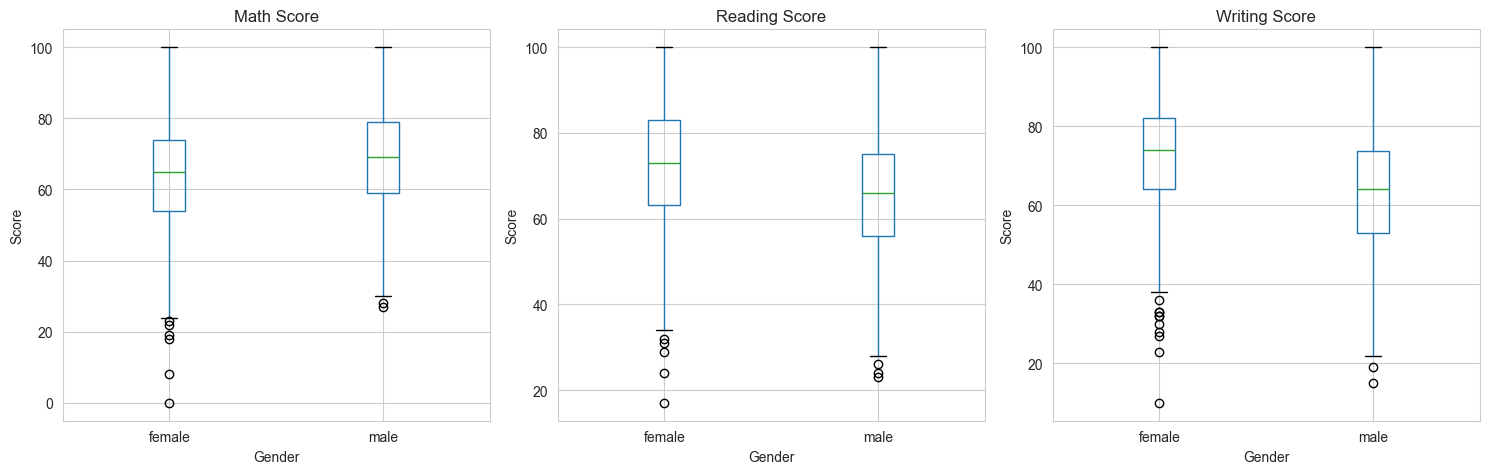

In [5]:
print("2. CREATING VISUALIZATIONS")
print("="*70)

# Set style
sns.set_style("whitegrid")

# VISUALIZATION 1: Score Distribution by Gender
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Visualization 1: Score Distribution by Gender', fontsize=16, fontweight='bold')

subjects = ['math score', 'reading score', 'writing score']
for idx, subject in enumerate(subjects):
    df.boxplot(column=subject, by='gender', ax=axes[idx])
    axes[idx].set_title(subject.title())
    axes[idx].set_xlabel('Gender')
    axes[idx].set_ylabel('Score')
    axes[idx].get_figure().suptitle('')

plt.tight_layout()
plt.savefig('viz1_gender_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Saved: viz1_gender_distribution.png")
plt.show()

✓ Saved: viz2_correlation.png


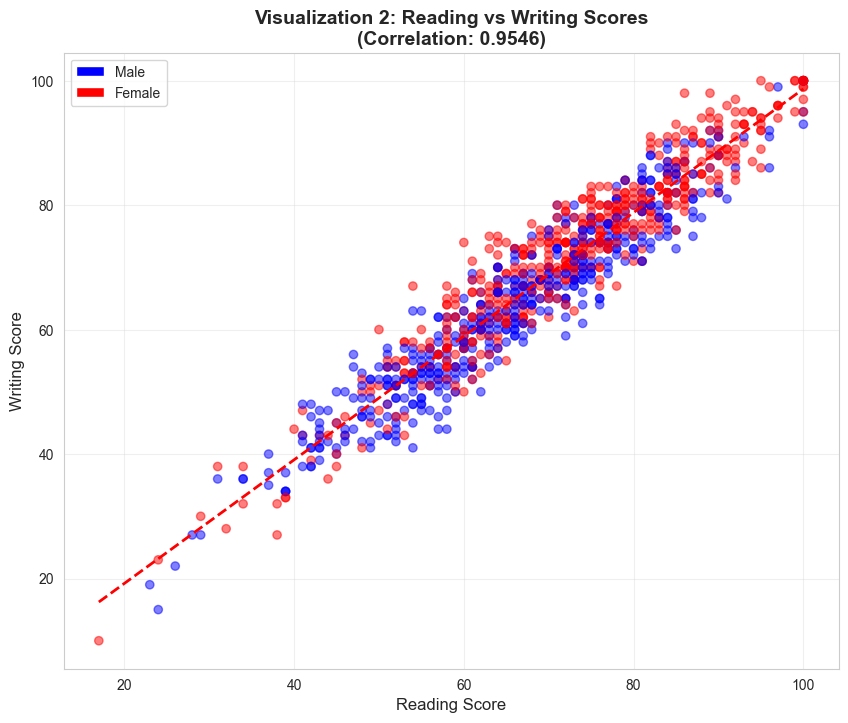

In [6]:
# VISUALIZATION 2: Reading vs Writing Correlation
plt.figure(figsize=(10, 8))
colors = df['gender'].map({'male': 'blue', 'female': 'red'})
plt.scatter(df['reading score'], df['writing score'], alpha=0.5, c=colors)
plt.xlabel('Reading Score', fontsize=12)
plt.ylabel('Writing Score', fontsize=12)
plt.title(f'Visualization 2: Reading vs Writing Scores\n(Correlation: {correlation:.4f})', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(df['reading score'], df['writing score'], 1)
p = np.poly1d(z)
plt.plot(df['reading score'].sort_values(), p(df['reading score'].sort_values()), 
         "r--", linewidth=2, label='Trend line')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', label='Male'),
                   Patch(facecolor='red', label='Female')]
plt.legend(handles=legend_elements)

plt.savefig('viz2_correlation.png', dpi=300, bbox_inches='tight')
print("✓ Saved: viz2_correlation.png")
plt.show()

✓ Saved: viz3_comprehensive_analysis.png


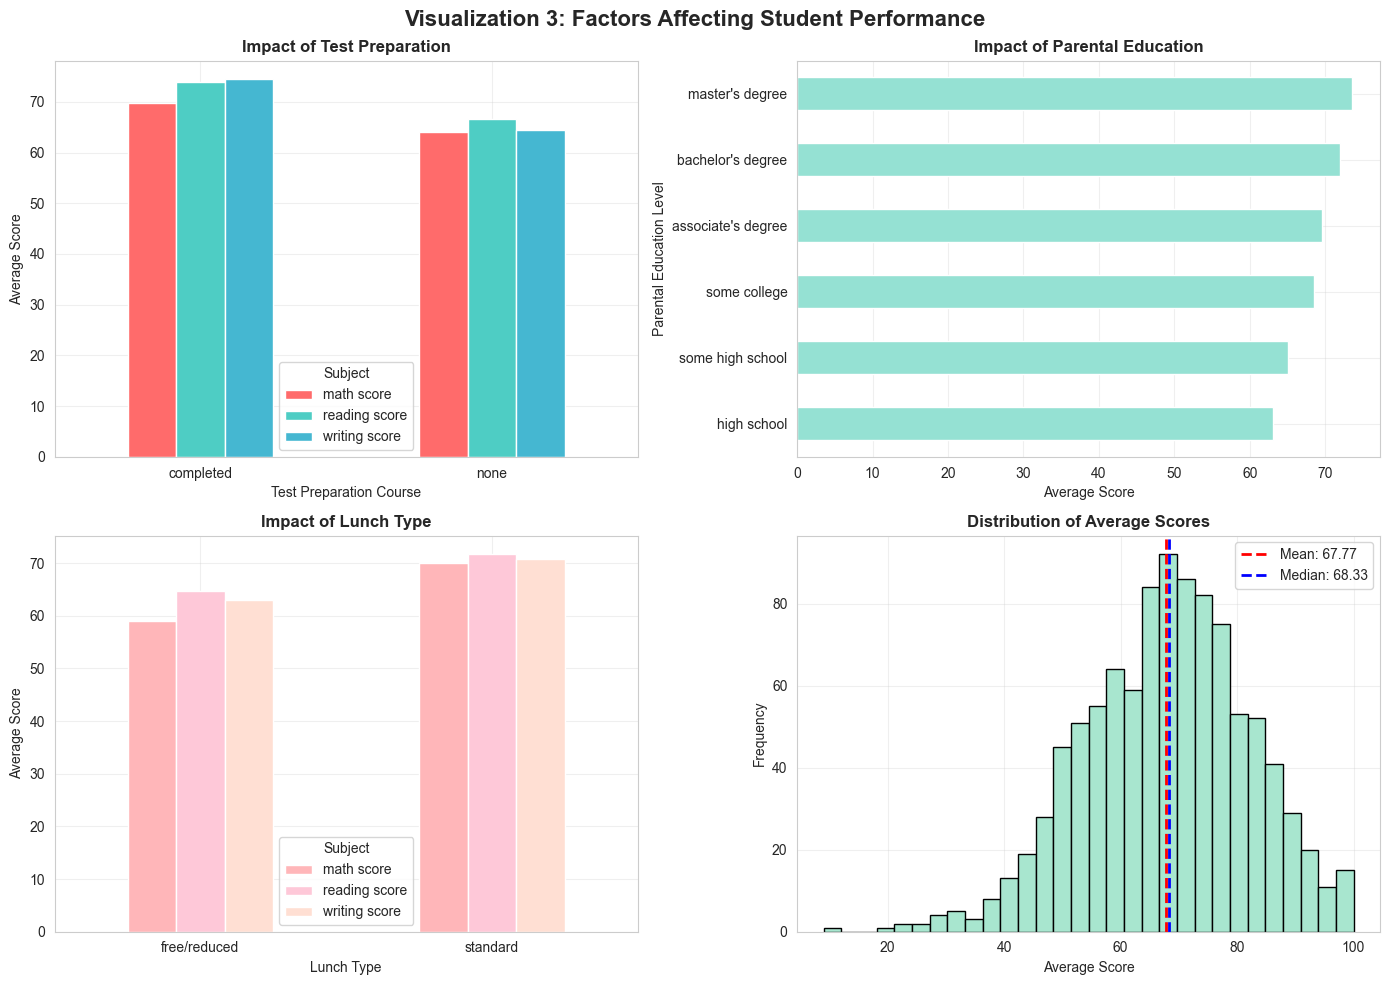

In [7]:
# VISUALIZATION 3: Comprehensive Factors Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Visualization 3: Factors Affecting Student Performance', 
             fontsize=16, fontweight='bold')

# Test prep
test_prep_data = df.groupby('test preparation course')[['math score', 'reading score', 'writing score']].mean()
test_prep_data.plot(kind='bar', ax=axes[0, 0], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0, 0].set_title('Impact of Test Preparation', fontweight='bold')
axes[0, 0].set_xlabel('Test Preparation Course')
axes[0, 0].set_ylabel('Average Score')
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=0)
axes[0, 0].legend(title='Subject')
axes[0, 0].grid(True, alpha=0.3)

# Parental education
parent_scores = df.groupby('parental level of education')['average_score'].mean().sort_values()
parent_scores.plot(kind='barh', ax=axes[0, 1], color='#95E1D3')
axes[0, 1].set_title('Impact of Parental Education', fontweight='bold')
axes[0, 1].set_xlabel('Average Score')
axes[0, 1].set_ylabel('Parental Education Level')
axes[0, 1].grid(True, alpha=0.3)

# Lunch type
lunch_data = df.groupby('lunch')[['math score', 'reading score', 'writing score']].mean()
lunch_data.plot(kind='bar', ax=axes[1, 0], color=['#FFB6B9', '#FEC8D8', '#FFDFD3'])
axes[1, 0].set_title('Impact of Lunch Type', fontweight='bold')
axes[1, 0].set_xlabel('Lunch Type')
axes[1, 0].set_ylabel('Average Score')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=0)
axes[1, 0].legend(title='Subject')
axes[1, 0].grid(True, alpha=0.3)

# Overall distribution
axes[1, 1].hist(df['average_score'], bins=30, color='#A8E6CF', edgecolor='black')
axes[1, 1].axvline(df['average_score'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {df["average_score"].mean():.2f}')
axes[1, 1].axvline(df['average_score'].median(), color='blue', linestyle='--', 
                   linewidth=2, label=f'Median: {df["average_score"].median():.2f}')
axes[1, 1].set_title('Distribution of Average Scores', fontweight='bold')
axes[1, 1].set_xlabel('Average Score')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('viz3_comprehensive_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Saved: viz3_comprehensive_analysis.png")
plt.show()

In [9]:
# 3. DOCUMENT 3 KEY INSIGHTS
# =============================================================================
print("\n" + "="*70)
print("3. KEY INSIGHTS")
print("="*70)

# Insight 1: Gender gap in math
male_math = df[df['gender'] == 'male']['math score'].mean()
female_math = df[df['gender'] == 'female']['math score'].mean()
gap = male_math - female_math
# Insight 1: Gender gap in math
male_math = df[df['gender'] == 'male']['math score'].mean()
female_math = df[df['gender'] == 'female']['math score'].mean()
gap = male_math - female_math

print(f"\n📊 INSIGHT 1: Gender Gap in Math Performance")
print(f"   • Male average: {male_math:.2f}")
print(f"   • Female average: {female_math:.2f}")
print(f"   • Gap: {gap:.2f} points ({(gap/female_math*100):.1f}% difference)")
print(f"   • Males score significantly higher in mathematics")



3. KEY INSIGHTS

📊 INSIGHT 1: Gender Gap in Math Performance
   • Male average: 68.73
   • Female average: 63.63
   • Gap: 5.10 points (8.0% difference)
   • Males score significantly higher in mathematics


In [10]:
# Insight 2: Test preparation effectiveness
completed = df[df['test preparation course'] == 'completed']['average_score'].mean()
none = df[df['test preparation course'] == 'none']['average_score'].mean()
improvement = completed - none

print(f"\n📚 INSIGHT 2: Test Preparation Course Effectiveness")
print(f"   • With preparation: {completed:.2f}")
print(f"   • Without preparation: {none:.2f}")
print(f"   • Improvement: +{improvement:.2f} points ({(improvement/none*100):.1f}% increase)")
print(f"   • Test prep courses show significant positive impact")



📚 INSIGHT 2: Test Preparation Course Effectiveness
   • With preparation: 72.67
   • Without preparation: 65.04
   • Improvement: +7.63 points (11.7% increase)
   • Test prep courses show significant positive impact


In [11]:
# Insight 3: Socioeconomic impact
standard = df[df['lunch'] == 'standard']['average_score'].mean()
reduced = df[df['lunch'] == 'free/reduced']['average_score'].mean()
socio_gap = standard - reduced

print(f"\n💰 INSIGHT 3: Socioeconomic Impact (Lunch Type as Proxy)")
print(f"   • Standard lunch: {standard:.2f}")
print(f"   • Free/reduced lunch: {reduced:.2f}")
print(f"   • Gap: {socio_gap:.2f} points ({(socio_gap/reduced*100):.1f}% difference)")
print(f"   • Significant correlation between economic status and performance")


💰 INSIGHT 3: Socioeconomic Impact (Lunch Type as Proxy)
   • Standard lunch: 70.84
   • Free/reduced lunch: 62.20
   • Gap: 8.64 points (13.9% difference)
   • Significant correlation between economic status and performance


In [5]:
import matplotlib.pyplot as plt
import matplotlib_venn as venn

ModuleNotFoundError: No module named 'matplotlib_venn'